In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data (2).csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
# Размер таблицы и общая информация
print(df.shape)
df.info()

(301355, 5)
<class 'pandas.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Дата          301355 non-null  str  
 1   Склад         301355 non-null  int64
 2   Контрагент    301355 non-null  str  
 3   Номенклатура  301355 non-null  str  
 4   Количество    301355 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.5 MB


Проверяем формат столбцов

In [4]:
df.dtypes

Дата              str
Склад           int64
Контрагент        str
Номенклатура      str
Количество      int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])
df.dtypes

Дата            datetime64[us]
Склад                    int64
Контрагент                 str
Номенклатура               str
Количество               int64
dtype: object

Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = (df.groupby('Дата', as_index=False)['Количество'].sum()
                .rename(columns={'Количество': 'Количество продаж'}))

Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

,Дата,Количество продаж
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

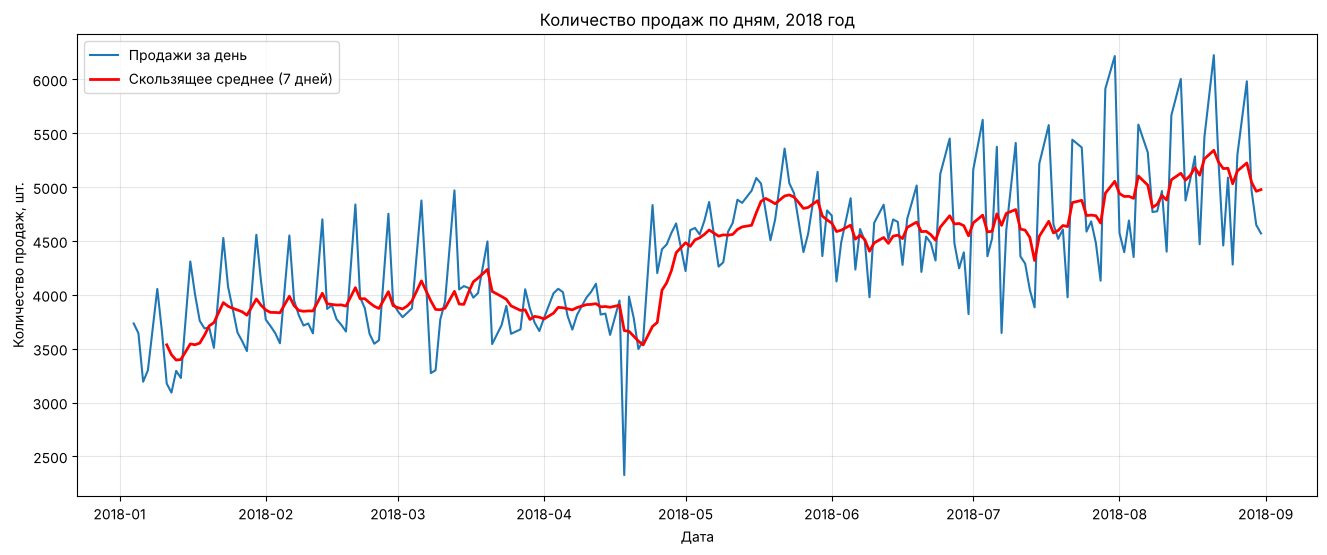

In [8]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=grouped_df, x='Дата', y='Количество продаж', label='Продажи за день')

# Скользящее среднее за 7 дней, чтобы был виден тренд
plt.plot(grouped_df['Дата'],
         grouped_df['Количество продаж'].rolling(7).mean(),
         color='red', linewidth=2, label='Скользящее среднее (7 дней)')

plt.title('Количество продаж по дням, 2018 год')
plt.xlabel('Дата')
plt.ylabel('Количество продаж, шт.')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

**Что видно на графике**

1. **Период данных:** с 4 января по 31 августа 2018 года, 205 дней с продажами. В среднем продаётся около 4 340 шт. в день (минимум 2 326, максимум 6 226).
2. **Восходящий тренд.** Продажи растут в течение всего периода: скользящее среднее поднимается примерно с 3 500 шт./день в начале января до ~5 000 шт./день в конце августа (+40%). Среднедневные продажи по месяцам: январь ≈ 3 716, апрель ≈ 3 953, май ≈ 4 720, август ≈ 5 016.
3. **Скачок в конце апреля.** С января до середины апреля продажи почти на одном уровне (~3 700–4 000 шт./день). Примерно с 20–25 апреля уровень резко поднимается и к маю выходит на ~4 700, а дальше держится высоким. В июне небольшая просадка (≈ 4 540), затем рост в июле–августе. Похоже на сезонный спрос на летние товары.
4. **Сильная недельная сезонность** — отсюда «пила» на графике. В понедельник продаж нет совсем (в данных нет ни одного понедельника), поэтому во вторник пик: в среднем ≈ 4 910 шт. против ≈ 4 230–4 390 в остальные дни. Самый слабый день — пятница (≈ 3 980).
5. **Пропуски.** Помимо всех понедельников, нет данных за 22 марта 2018 г. (четверг) — это праздник Наурыз.
6. **Выбросы.** Самый низкий день — 18 апреля (2 326 шт.), заметно ниже соседних дней. Возможно, неполная выгрузка или сбой. Максимумы приходятся на вторники конца лета: 21 августа (6 226), 14 и 28 августа, а также 31 июля (6 217).
7. **Разброс со временем увеличивается.** Летом колебания между днями больше, чем зимой: растёт и уровень продаж, и амплитуда.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
# Строка с максимальным количеством в одной продаже
max_row = df.loc[df['Количество'].idxmax()]
print(max_row)

# Проверим, что это действительно выброс: метод межквартильного размаха (IQR)
q1 = df['Количество'].quantile(0.25)
q3 = df['Количество'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f'Q1 = {q1}, Q3 = {q3}, верхняя граница выбросов = {upper}')
print('Топ-5 строк по количеству:')
df.sort_values('Количество', ascending=False).head()

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object
Q1 = 1.0, Q3 = 4.0, верхняя граница выбросов = 8.5
Топ-5 строк по количеству:


,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200
260398,2018-07-31,4,address_125,product_1,140
260399,2018-07-31,4,address_125,product_2,100
258867,2018-07-29,4,address_142,product_1,80
258868,2018-07-29,4,address_142,product_2,70


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [10]:
# Склад 3, среды (dayofweek == 2), июнь–август
summer_wed = df[(df['Склад'] == 3)
                & (df['Дата'].dt.dayofweek == 2)
                & (df['Дата'].dt.month.isin([6, 7, 8]))]

top_products = (summer_wed.groupby('Номенклатура')['Количество'].sum()
                .sort_values(ascending=False))
top_products.head()

Номенклатура
product_1    2267
product_2    2060
product_0    1324
product_3     914
product_6     650
Name: Количество, dtype: int64

In [11]:
print('Топовый товар:', top_products.index[0], '—', top_products.iloc[0], 'шт.')

Топовый товар: product_1 — 2267 шт.


**Ответы:**
- Максимальный выброс — строка с индексом **218822**: 28.06.2018, склад 1, контрагент `address_208`, товар `product_0`, **200 шт.** При типичной продаже 1–4 шт. (граница выбросов по IQR = 8.5) это в ~67 раз больше среднего (≈ 3 шт.). Следующий по величине — 140 шт.
- Топовый товар по средам за июнь–август на складе 3 — **product_1** (2 267 шт.), на втором месте product_2 (2 060 шт.).

Обработай файл Погода в Астане.csv, объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [12]:
# Читаем файл погоды: строки с '#' — служебные комментарии rp5.ru, разделитель ';'
weather = pd.read_csv('Погода в Астане.csv', sep=';', comment='#', index_col=False,
                      usecols=['Местное время в Астане', 'T'])
weather['Дата_время'] = pd.to_datetime(weather['Местное время в Астане'], format='%d.%m.%Y %H:%M')
weather['Дата'] = weather['Дата_время'].dt.normalize()

# Наблюдения идут каждые 3 часа — считаем среднюю температуру за сутки
daily_t = weather.groupby('Дата', as_index=False)['T'].mean()
daily_t['T'] = daily_t['T'].round(1)
print('Период погоды:', daily_t['Дата'].min().date(), '—', daily_t['Дата'].max().date())
print('Период продаж:', grouped_df['Дата'].min().date(), '—', grouped_df['Дата'].max().date())

# Объединяем по дате
merged = grouped_df.merge(daily_t, on='Дата', how='left')
print('Дней с известной температурой:', merged['T'].notna().sum(), 'из', len(merged))
merged.head()

Период погоды: 2018-01-01 — 2018-12-31
Период продаж: 2018-01-04 — 2018-08-31
Дней с известной температурой: 205 из 205


,Дата,Количество продаж,T
0,2018-01-04,3734,-14.1
1,2018-01-05,3643,-16.9
2,2018-01-06,3193,-13.3
3,2018-01-07,3298,-12.8
4,2018-01-09,4055,-6.2


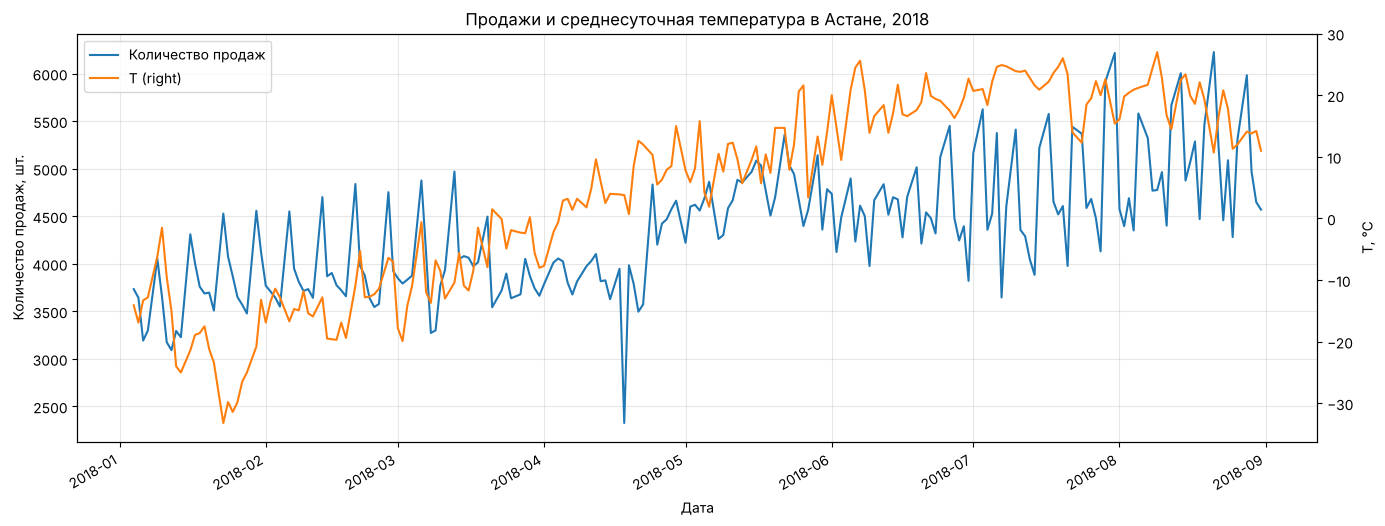

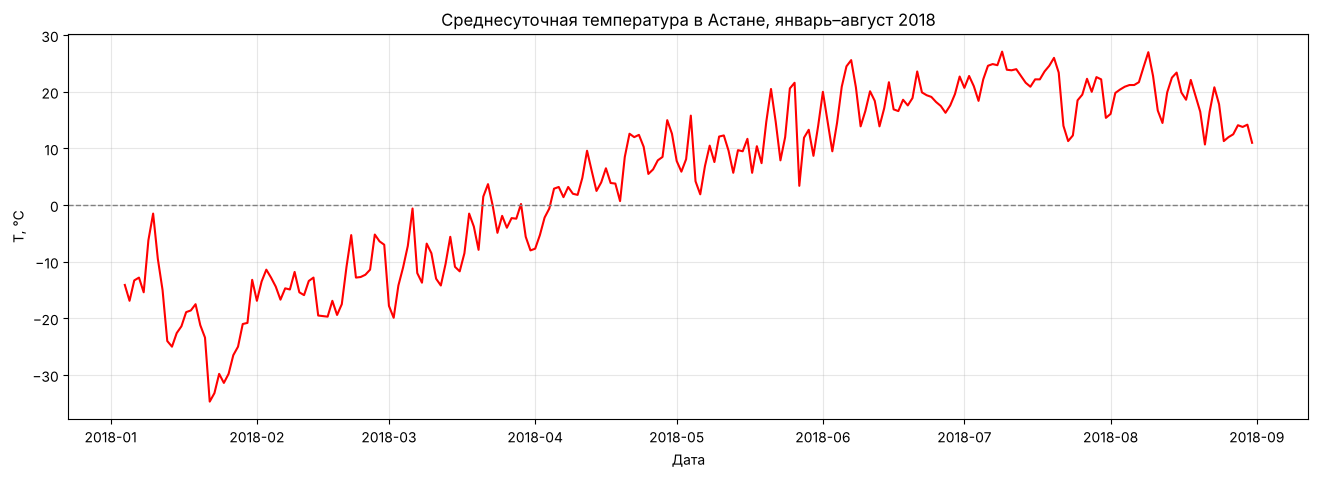

In [13]:
# Совместный график y=['Количество продаж', 'T'] (температура — на правой оси, т.к. масштабы разные)
ax = merged.plot(x='Дата', y=['Количество продаж', 'T'], secondary_y='T', figsize=(16, 6),
                 title='Продажи и среднесуточная температура в Астане, 2018')
ax.set_ylabel('Количество продаж, шт.')
ax.right_ax.set_ylabel('T, °C')
ax.grid(alpha=0.3)
plt.show()

# Отдельный график температуры за тот же период
temp_period = daily_t[(daily_t['Дата'] >= grouped_df['Дата'].min()) & (daily_t['Дата'] <= grouped_df['Дата'].max())]
plt.figure(figsize=(16, 5))
plt.plot(temp_period['Дата'], temp_period['T'], color='red')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Среднесуточная температура в Астане, январь–август 2018')
plt.xlabel('Дата')
plt.ylabel('T, °C')
plt.grid(alpha=0.3)
plt.show()

In [14]:
# Насколько продажи связаны с температурой
print('Корреляция продаж и температуры:', round(merged['Количество продаж'].corr(merged['T']), 2))

# Средние по месяцам
monthly = merged.set_index('Дата').resample('ME')[['Количество продаж', 'T']].mean().round(1)
monthly.index = monthly.index.strftime('%Y-%m')
print(monthly)

# Убираем общий тренд (отклонение от скользящего среднего за 7 дней) — есть ли связь день ко дню?
sales_dev = merged['Количество продаж'] - merged['Количество продаж'].rolling(7, center=True).mean()
t_dev = merged['T'] - merged['T'].rolling(7, center=True).mean()
print('Корреляция дневных отклонений:', round(sales_dev.corr(t_dev), 2))

Корреляция продаж и температуры: 0.6
         Количество продаж     T
Дата                            
2018-01             3716.0 -19.5
2018-02             3910.0 -13.8
2018-03             3925.5  -7.6
2018-04             3953.3   5.0
2018-05             4720.0  10.3
2018-06             4539.8  18.6
2018-07             4794.4  21.5
2018-08             5015.6  18.3
Корреляция дневных отклонений: -0.03


**Вывод по температуре**

- Температура за период: от −34,7 °C (22 января) до +27 °C (9 июля). Среднемесячно: от −19,5 °C в январе до +21,5 °C в июле, в августе снова немного прохладнее (+18,3 °C).
- **Продажи и температура растут вместе:** корреляция ≈ **0,60**, это умеренная положительная связь. Чем теплее месяц, тем выше средние продажи.
- Особенно заметно весной: резкий скачок продаж в конце апреля совпадает с моментом, когда среднесуточная температура с 20 апреля устойчиво поднялась выше +8…+12 °C. Продажи переходят на «летний» уровень вместе с потеплением.
- Связь не полная. В августе температура ниже, чем в июле, а продажи продолжают расти. В июне жарче, чем в мае, а продажи чуть ниже. Значит, кроме погоды, на рост влияет общий тренд бизнеса.
- **День ко дню погода на продажи почти не влияет:** если убрать общий тренд, корреляция отклонений ≈ 0. Резкие похолодания или жаркие дни не дают всплесков или провалов, а «пила» на графике объясняется днями недели. Температура работает как сезонный фактор, а не как ежедневный.